# Model Evaluation Figures (Demo)

This notebook exports predictions for a fixed test split and generates evaluation figures.

- Input: trained weights (`*.weights.h5`) and the saved test id list (`*.test_ids.npy`)
- Output: one `*.eval.npz` file and a folder of figures


In [1]:
import os
import sys
import json

ROOT = "/Users/liuxi/Desktop/RFA_GNN"
if not os.path.exists(ROOT):
    ROOT = os.getcwd()
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print("ROOT=", ROOT)
print("SRC =", SRC)


ROOT= /Users/liuxi/Desktop/RFA_GNN
SRC = /Users/liuxi/Desktop/RFA_GNN/src


## Paths

Update the paths below to point to your trained model.


In [2]:
weights_path = os.path.join(ROOT, "saved_models", "gat_executed.weights.h5")
meta_path = os.path.join(ROOT, "saved_models", "gat_executed.meta.json")
test_ids_path = os.path.splitext(meta_path)[0] + ".test_ids.npy"

out_npz = os.path.join(ROOT, "tmp", "gat_executed.eval.npz")
out_fig_dir = os.path.join(ROOT, "tmp", "gat_executed.fig")

print("weights_path:", weights_path)
print("meta_path   :", meta_path)
print("test_ids    :", test_ids_path)
print("out_npz     :", out_npz)
print("out_fig_dir :", out_fig_dir)


weights_path: /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_executed.weights.h5
meta_path   : /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_executed.meta.json
test_ids    : /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_executed.meta.test_ids.npy
out_npz     : /Users/liuxi/Desktop/RFA_GNN/tmp/gat_executed.eval.npz
out_fig_dir : /Users/liuxi/Desktop/RFA_GNN/tmp/gat_executed.fig


## Export predictions (fixed test split)

This step loads data, builds the model architecture, loads the weights, and runs inference.

The test set is selected by `test_ids_path` to ensure it matches the training split.


In [3]:
import os

from plot_eval_figures import ExportArgs, export_predictions, generate_test_ids_npy

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

#test_ids_path = meta.get("test_ids_npy", test_ids_path)
if not os.path.exists(test_ids_path):
    print("test_ids not found, generating:", test_ids_path)
    generate_test_ids_npy(meta_path=meta_path, out_path=test_ids_path, root=ROOT)
else:
    print("test_ids found:", test_ids_path)

args = ExportArgs(
    root=ROOT,
    weights=weights_path,
    out=out_npz,
    cell_line=meta.get("cell_line", "MCF7"),
    use_landmark_genes=bool(meta.get("use_landmark_genes", True)),
    max_samples=0,
    split_mode=meta.get("split_mode", "cold_drug"),
    test_frac=float(meta.get("test_frac", 0.2)),
    sparse_gat=bool(meta.get("sparse_gat", True)),
    use_drug_fp_embedding=bool(meta.get("use_drug_fp_embedding", False)),
    hidden_dim=int(meta.get("hidden_dim", 64)),
    num_heads=int(meta.get("num_heads", 4)),
    dropout=float(meta.get("dropout", 0.2)),
    attention_layers=int(meta.get("attention_layers", 4)),
    per_node_head=bool(meta.get("per_node_head", True)),
    no_cell_embedding=bool(meta.get("no_cell_embedding", False)),
    no_residualize_target_by_cell=bool(meta.get("no_residualize_target_by_cell", False)),
    eval_drug_zero=True,
    eval_drug_shuffle=True,
    eval_sanity_seed=0,
    eval_sanity_max_eval=20000,
    test_ids_npy=test_ids_path,
    export_attention=True,
    attention_max_samples=2000,
    attention_batch_size=64
)

export_predictions(args)
print("Saved:", out_npz)


test_ids found: /Users/liuxi/Desktop/RFA_GNN/saved_models/gat_executed.meta.test_ids.npy
正在加载 RFA 数据 (Landmark Mode: True)...
CSV路径: CTL=/Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_ctl_n188708x12328.h5, TRT=/Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_trt_cp_n1805898x12328.h5
目标基因数: 978
正在读取元数据: /Users/liuxi/Desktop/RFA_GNN/data/siginfo_beta.txt
过滤后元数据记录数: 117284
发现 57929 个 Control 样本，涉及 162 个细胞系。
正在加载所有 Control 数据以计算均值...
正在加载数据文件: /Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_ctl_n188708x12328.h5 ...
  H5 (h5py): 匹配到 57929 个样本 (axis0/Index). 读取中...
  读取耗时: 24.83s
  Gene ID 匹配: Index=0, Columns=978
  形状检查: Rows=57929, Target=978
  已筛选并对齐到 978 个 Genes。
发现 67663 个高质量 Treatment 样本。
正在加载 Treatment 数据...
正在加载数据文件: /Users/liuxi/Desktop/RFA_GNN/data/cmap/level3_beta_trt_cp_n1805898x12328.h5 ...
  H5 (h5py): 匹配到 67663 个样本 (axis0/Index). 读取中...
  读取耗时: 38.33s
  Gene ID 匹配: Index=0, Columns=978
  形状检查: Rows=67663, Target=978
  已筛选并对齐到 978 个 Genes。
数据组装完成: (202881, 978)
正在加载药物靶

/opt/anaconda3/envs/RFA_GNN/lib/python3.11/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'base_line_gat', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Saved: /Users/liuxi/Desktop/RFA_GNN/tmp/gat_executed.eval.npz


## Generate figures (one cell per figure)


In [4]:
import os

from plot_eval_figures import load_eval_npz

os.makedirs(out_fig_dir, exist_ok=True)
run = load_eval_npz(out_npz)
tag = os.path.splitext(os.path.basename(out_npz))[0]
print("tag=", tag)


tag= gat_executed.eval


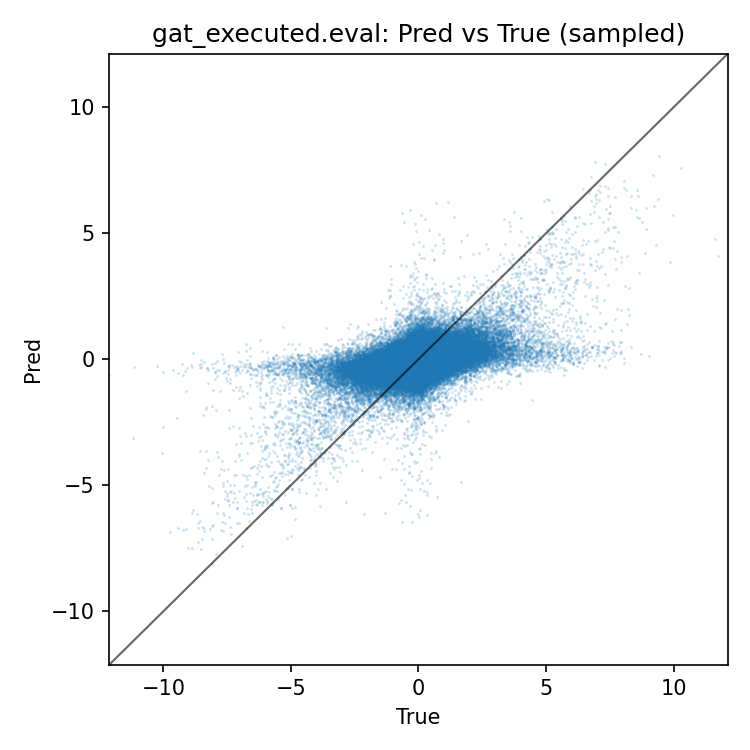

In [23]:
from plot_eval_figures import plot_true_pred_scatter

plot_true_pred_scatter(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_scatter_all.png"),
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_scatter_all.png")))

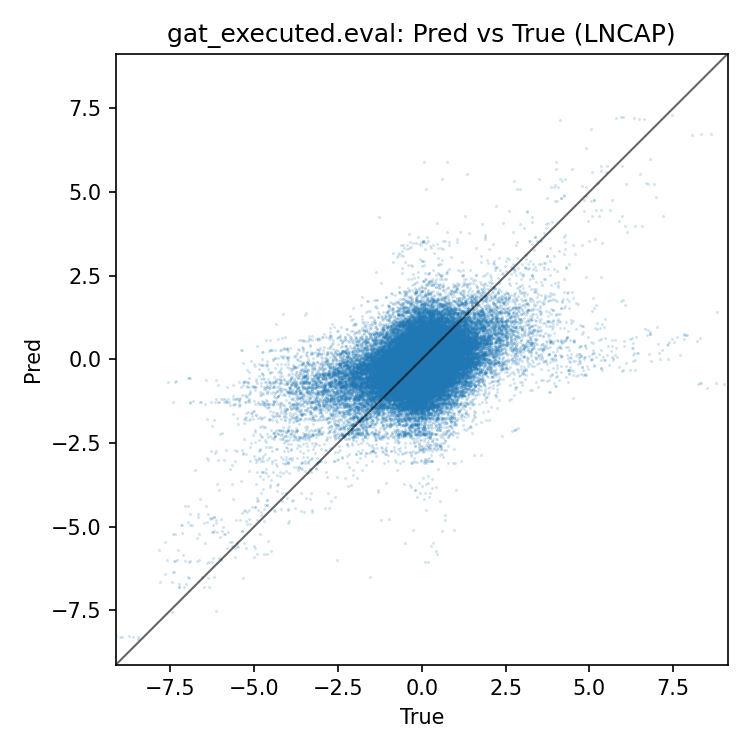

In [18]:
from plot_eval_figures import plot_true_pred_scatter_for_cell

plot_true_pred_scatter_for_cell(
    run,
    cell_name="LNCAP",
    out_path=os.path.join(out_fig_dir, f"{tag}_scatter_cell_LNCAP.png"),
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_scatter_cell_LNCAP.png")))

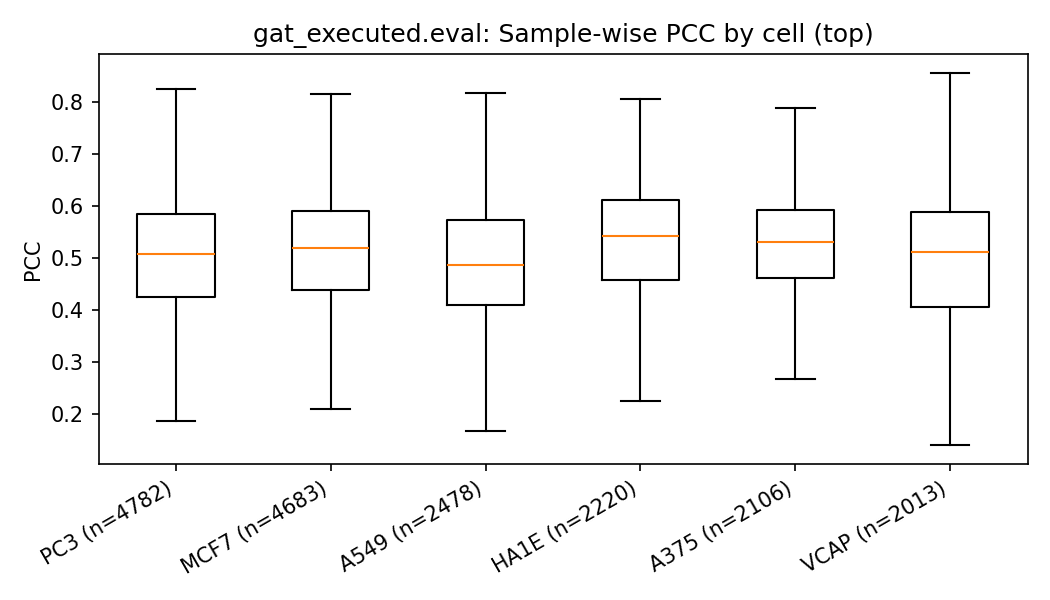

In [20]:
from plot_eval_figures import plot_sample_pcc_by_cell

plot_sample_pcc_by_cell(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_pcc_by_cell.png"),
    top_k=6,
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_pcc_by_cell.png")))

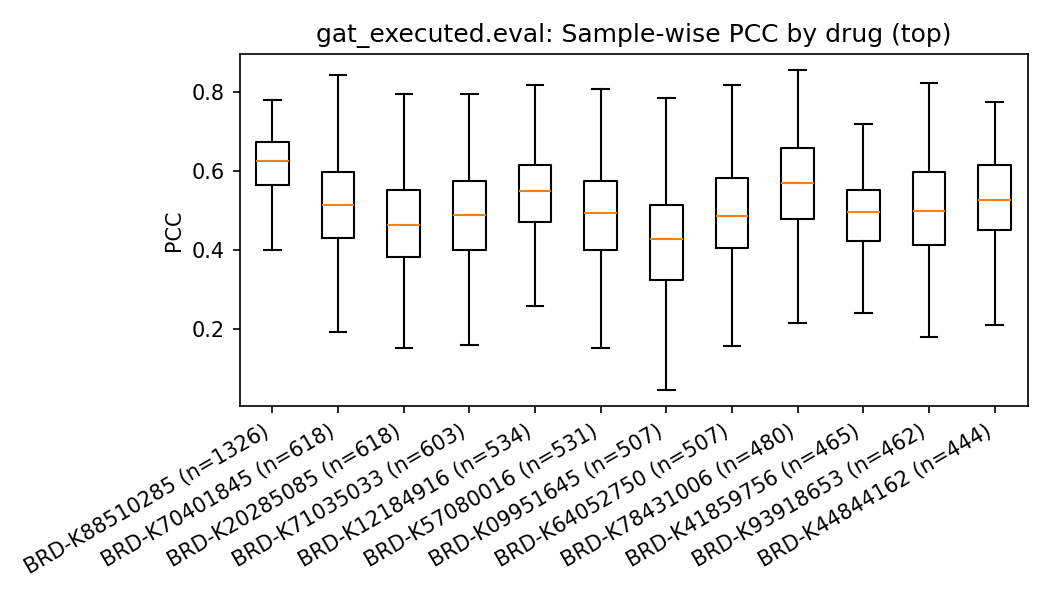

In [19]:
from plot_eval_figures import plot_sample_pcc_by_drug

plot_sample_pcc_by_drug(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_pcc_by_drug.png"),
    top_k=12,
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_pcc_by_drug.png")))

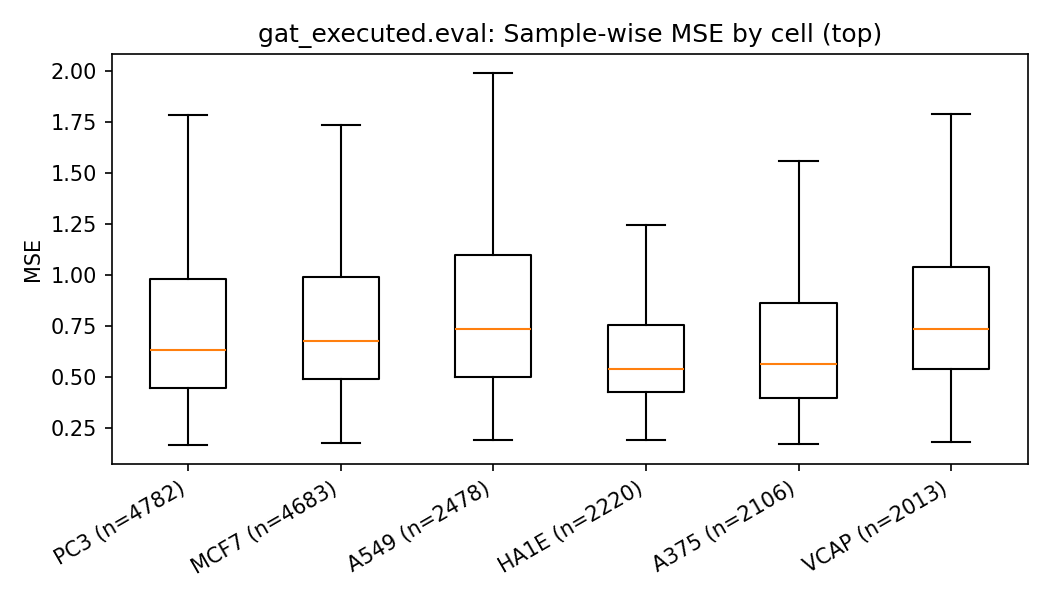

In [21]:
from plot_eval_figures import plot_sample_mse_by_cell

plot_sample_mse_by_cell(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_mse_by_cell.png"),
    top_k=6,
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_mse_by_cell.png")))

In [10]:
from plot_eval_figures import plot_sanity_pcc

plot_sanity_pcc(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_sanity_pcc.png"),
)


In [11]:
from plot_eval_figures import plot_delta_pcc

plot_delta_pcc(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_delta_pcc.png"),
)


In [12]:
print("Figures saved to:", out_fig_dir)


Figures saved to: /Users/liuxi/Desktop/RFA_GNN/tmp/gat_executed.fig


## Quick preview


In [22]:
# from glob import glob
# from IPython.display import Image, display

# pngs = sorted(glob(os.path.join(out_fig_dir, "*.png")))
# print("num png:", len(pngs))
# for p in pngs[:8]:
#     print(os.path.basename(p))
#     display(Image(filename=p))


In [14]:
att = run.get("attention", {})
print(att.keys())
print("edge_mean shape:", att["attention_edge_mean"].shape)  # (L, E)
print("edge_index shape:", att["edge_index"].shape)          # (2, E)
print("num samples used:", att.get("attention_num_samples"))

dict_keys(['attention_edge_mean', 'edge_index', 'edge_weight', 'attention_num_samples'])
edge_mean shape: (4, 3728)
edge_index shape: (2, 3728)
num samples used: 2000


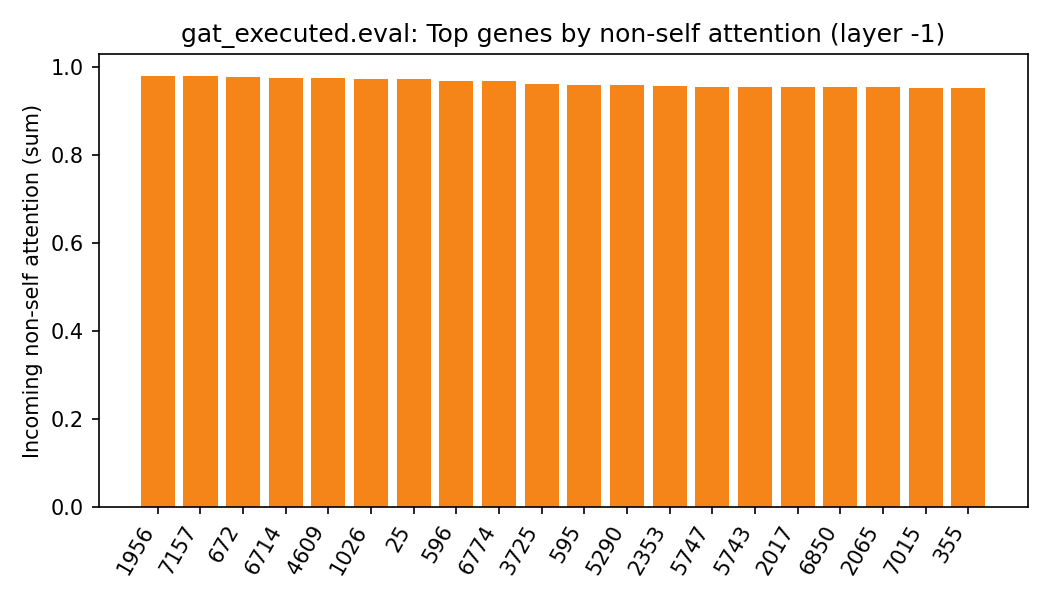

In [15]:
from plot_eval_figures import plot_attention_top_genes
from IPython.display import Image, display
import os

plot_attention_top_genes(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_attn_top_genes.png"),
    top_k=20,
    layer=-1,   # -1 表示最后一层；也可以 0/1/2/3
)
display(Image(filename=os.path.join(out_fig_dir, f"{tag}_attn_top_genes.png")))

In [16]:
import importlib
from plot_eval_figures import export_attention_top_edges_csv
import plot_eval_figures as pef
importlib.reload(pef)
df_edges = export_attention_top_edges_csv(
    run,
    out_path=os.path.join(out_fig_dir, f"{tag}_attn_top_edges.csv"),
    top_k=50,
    layer=-1,
)
df_edges.head(15)


,src_idx,dst_idx,src_gene,dst_gene,attention
0,471,195,207,23647,0.669130
1,895,461,5925,7159,0.665595
2,839,619,3091,8985,0.658640
3,839,54,3091,23210,0.657317
4,839,569,3091,55847,0.656964
5,471,726,207,7994,0.652154
6,365,273,8091,10644,0.651594
7,839,975,3091,4931,0.648686
8,839,797,3091,5529,0.646337
9,818,376,5601,9467,0.641708


In [17]:
import pandas as pd
import os

gene_info_path = os.path.join(ROOT, "data", "GSE92742_Broad_LINCS_gene_info.txt")
gi = pd.read_csv(gene_info_path, sep="\t")

entrez2symbol = dict(zip(gi["pr_gene_id"].astype(str), gi["pr_gene_symbol"].astype(str)))

df_edges["src_symbol"] = df_edges["src_gene"].astype(str).map(entrez2symbol)
df_edges["dst_symbol"] = df_edges["dst_gene"].astype(str).map(entrez2symbol)

df_edges[["src_symbol", "dst_symbol", "attention"]].head(15)

,src_symbol,dst_symbol,attention
0,AKT1,ARFIP2,0.669130
1,RB1,TP53BP2,0.665595
2,HIF1A,PLOD3,0.658640
3,HIF1A,JMJD6,0.657317
4,HIF1A,CISD1,0.656964
5,AKT1,KAT6A,0.652154
6,HMGA2,IGF2BP2,0.651594
7,HIF1A,NVL,0.648686
8,HIF1A,PPP2R5E,0.646337
9,MAPK9,SH3BP5,0.641708
